# Question 3 : AutoEncoders

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import datetime
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import glob
from skimage.io import imread
from sklearn.metrics import (
    roc_auc_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

In [12]:
# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## Question 3.2 : Anomaly Detection with Autoencoders

In [13]:
# Previously implemented MLP
# ============= Activation Function Classes =============

class ReLU:
    """ReLU activation function."""
    
    def forward(self, x):
        """Forward pass: max(0, x)"""
        self.input = x # Of size (batch_size, output_width)
        return np.maximum(0, x) # Element-wise max
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 if x > 0, else 0"""
        return grad_output * (self.input >= 0) # Of same shape as input


class Tanh:
    """Tanh activation function."""
    
    def forward(self, x):
        """Forward pass: tanh(x)"""
        self.output = np.tanh(x) # Of size (batch_size, output_width)
        return self.output # Element-wise tanh
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 - tanh^2(x)"""
        return grad_output * (1 - self.output ** 2) # Of same shape as input


class Sigmoid:
    """Sigmoid activation function."""
    
    def forward(self, x):
        """Forward pass: 1 / (1 + exp(-x))"""
        self.output = 1 / (1 + np.exp(-np.clip(x, -500, 500))) # Clip to prevent overflow, Of size (batch_size, output_width)
        return self.output # Element-wise sigmoid
    
    def backward(self, grad_output):
        """Backward pass: sigmoid(x) * (1 - sigmoid(x))"""
        return grad_output * self.output * (1 - self.output) # Of same shape as input


class Identity:
    """Identity activation (no activation)."""
    
    def forward(self, x):
        """Forward pass: returns input as-is"""
        return x # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """Backward pass: gradient passes through unchanged"""
        return grad_output # Of same shape as input

# ============= Linear Layer Class =============

class Linear:
    """Linear (fully connected) layer."""
    
    def __init__(self, input_width, output_width, activation='relu'):
        """
        Initialize linear layer.
        
        Args:
            input_width: Number of input features
            output_width: Number of output features
            activation: Activation function name ('relu', 'tanh', 'sigmoid', 'identity')
        """

        random.seed(42)
        np.random.seed(42)

        self.input_width = input_width
        self.output_width = output_width
        
        # Initialize weights and biases using Xavier initialization
        self.weights = np.random.randn(input_width, output_width) * np.sqrt(2.0 / input_width)
        self.biases = np.zeros((1, output_width))
        
        # Initialize cumulative gradients
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)
        
        # Set activation function
        activation_map ={
            'relu': ReLU(),
            'tanh': Tanh(),
            'sigmoid': Sigmoid(),
            'identity': Identity()
        }
        # Get the 'Value' value from the key in the dictionary, pass the key in all lowercase, dedfault to ReLU
        self.activation = activation_map.get(activation.lower(), ReLU())
        
        # Store for backward pass
        self.input = None
        self.z = None
        self.output = None
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input of shape (batch_size, input_width)
            
        Returns:
            Output after linear transformation and activation
        """
        self.input = x # Of size (batch_size, input_width)
        self.z = np.dot(x, self.weights) + self.biases # Of size (batch_size, output_width)
        self.output = self.activation.forward(self.z) # Of size (batch_size, output_width)
        return self.output # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """
        Backward pass.
        
        Args:
            grad_output: Gradient from next layer
            
        Returns:
            Gradient to pass to previous layer
        """
        # Gradient through activation
        grad_z = self.activation.backward(grad_output) # Of size (batch_size, output_width)
        
        # Accumulate gradients for weights and biases
        self.grad_weights += np.dot(self.input.T, grad_z) # Of size (input_width, output_width)
        self.grad_biases += np.sum(grad_z, axis=0, keepdims=True) # Of size (1, output_width)
        
        # Gradient to pass to previous layer
        grad_input = np.dot(grad_z, self.weights.T) # Of size (batch_size, input_width)
        
        return grad_input # Of size (batch_size, input_width)
    
# ============= Loss Functions =============

class MSE:
    """Mean Squared Error loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute MSE loss."""
        self.y_pred = y_pred # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return (np.mean(y_pred - y_true) ** 2) # Scalar
    
    def backward(self):
        """Compute gradient of MSE loss."""
        batch_size, output_size = self.y_pred.shape
        return 2 * (self.y_pred - self.y_true) / (output_size * batch_size) # Of size (batch_size, output_width)


class BCE:
    """Binary Cross Entropy loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute BCE loss."""
        self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7) # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return -np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred), axis=1) # Scalar
    
    def backward(self):
        """Compute gradient of BCE loss."""
        batch_size, output_size = self.y_pred.shape
        return (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred) * output_size * batch_size) # Of size (batch_size, output_width)

# ============= Model Class =============

class Model:
    """Neural network model."""
    
    def __init__(self, layers, loss_type='mse'):
        """
        Initialize model.
        
        Args:
            layers: List of Linear layer objects
            loss_type: 'mse' or 'bce'
        """
        self.layers = layers

        if loss_type.lower() == 'mse':
            self.loss_fn = MSE()
        elif loss_type.lower() == 'bce':
            self.loss_fn = BCE()
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
    
    def forward(self, x):
        """
        Forward pass through all layers.
        
        Args:
            x: Input data
            
        Returns:
            Output predictions
        """
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def backward(self, grad_output):
        """
        Backward pass through all layers.
        
        Args:
            grad_output: Gradient from loss function
        """
        for layer in reversed(self.layers):
            grad_output = layer.backward(grad_output)
        return grad_output
    
    def train(self, x, y):
        """
        Perform one training step: forward pass, compute loss, backward pass.
        
        Args:
            x: Input data
            y: True labels
            
        Returns:
            loss: Computed loss value
        """
        # Forward pass
        y_pred = self.forward(x)
        
        # Compute loss
        loss = self.loss_fn.forward(y_pred, y)
        
        # Backward pass
        grad_loss = self.loss_fn.backward()
        self.backward(grad_loss)
        
        return loss
    
    def zero_grad(self):
        """Reset cumulative gradients in all layers to zero."""
        for layer in self.layers:
            layer.grad_weights.fill(0)
            layer.grad_biases.fill(0)
    
    def update(self, learning_rate):
        """
        Update model parameters using accumulated gradients.
        
        Args:
            learning_rate: Learning rate for gradient descent
        """
        for layer in self.layers:
            layer.weights -= learning_rate * layer.grad_weights
            layer.biases -= learning_rate * layer.grad_biases
    
    def predict(self, x):
        """
        Make predictions (forward pass without training).
        
        Args:
            x: Input data
            
        Returns:
            Predictions
        """
        return self.forward(x)
    
    def save_to(self, path, loss):
        """
        Save model parameters to file.
        
        Args:
            path: Path to save file (.npz format)
            loss: Loss value to include in filename
        """
        params = {}
        for i, layer in enumerate(self.layers):
            params[f'layer_{i}_weights'] = layer.weights
            params[f'layer_{i}_biases'] = layer.biases
        
        # Save architecture info
        architecture = {
            'num_layers': len(self.layers),
            'layer_shapes': [(layer.input_width, layer.output_width) for layer in self.layers],
            'activations': [layer.activation for layer in self.layers]
        }

        # Delete the previously saved model to save space
        for file in os.listdir(path):
            if file.startswith("model_loss_") and file.endswith(".npz"):
                os.remove(os.path.join(path, file))
    
        full_path = os.path.join(path, f"model_loss_{loss:.6f}.npz")
        np.savez(full_path, architecture=architecture, **params, loss=loss) # Unpacks params dict
        # print(f"Model saved to {full_path}")

    def load_from(self, path):
        """
        Load model parameters from file.
        
        Args:
            path: Path to saved file (.npz format)
        """
        data = np.load(path, allow_pickle=True) # To load non-numpy elements like dicts
        architecture = data['architecture'].item()
        
        # Verify architecture matches
        if len(self.layers) != architecture['num_layers']:
            raise ValueError("Model architecture doesn't match saved file!")
        
        for i, layer in enumerate(self.layers):
            expected_shape = architecture['layer_shapes'][i]
            if (layer.input_width, layer.output_width) != expected_shape:
                raise ValueError(f"Layer {i} shape mismatch!")
            
            layer.weights = data[f'layer_{i}_weights']
            layer.biases = data[f'layer_{i}_biases']
        
        print(f"Model loaded from {path}")



def plot_training_history(history):
    """
    Plot training loss vs epochs.
    
    Args:
        history: Dictionary from train_model
    """
    epoch_loss_history = history['loss_history']
    batch_loss_history = history['batch_loss_history']
    
    epochs = len(epoch_loss_history)
    epochs_axis = np.arange(1, epochs + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_axis, epoch_loss_history, linewidth=2, label='Epoch Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss per epoch', fontsize=12)
    plt.title(f'Training Loss vs Epochs', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    add_username("siddarth.g")
    # plt.ylim([0, 5e4])
    plt.show()

    # Loss vs samples seen
    # x_ticks = np.arange(1, len(history['grad_update_loss']) + 1) * history['hyperparameters']['batch_size'] * history['hyperparameters']['grad_accumulation_steps']

    # plt.figure(figsize=(10, 6))
    # plt.plot(x_ticks, history['grad_update_loss'], linewidth=2, label='Batch Loss')
    # plt.xlabel('Total Samples Seen', fontsize=12)
    # plt.ylabel('Loss per Grad Update', fontsize=12)
    # plt.title(f'Training Loss vs Total Samples Seen', fontsize=14)
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # add_username("siddarth.g")
    # plt.show()

In [14]:
class MLPAutoencoder:
    """
    An MLP-based Autoencoder class.
    It encapsulates an encoder and a decoder.
    """ 
    def __init__(self, encoder_layers, decoder_layers, loss='mse'):
        """
        Initializes the autoencoder by creating separate Model instances
        for the encoder and decoder.

        Args:
            encoder_layers (list): A list of Linear layer objects for the encoder.
            decoder_layers (list): A list of Linear layer objects for the decoder.
            loss_fn_type (str): The type of loss function to use ('mse' or 'bce').
        """
        # The encoder compresses the input to a lower-dimensional bottleneck
        self.encoder = Model(encoder_layers, loss)
        
        # The decoder reconstructs the input from the bottleneck representation
        self.decoder = Model(decoder_layers, loss)
    
    def forward(self, x):
        """Performs a full forward pass through the encoder and then the decoder."""
        encoded_representation = self.encoder.forward(x)
        reconstructed_output = self.decoder.forward(encoded_representation)
        return reconstructed_output
    
    def train(self, x):
        """
        Performs one full training step on an input batch 'x'.
        The goal is to reconstruct 'x', so the input and target are the same.
        """
        # Get the reconstructed output from the forward pass
        y_pred = self.forward(x)

        # Calculate the reconstruction loss and its initial gradient
        loss = self.decoder.loss_fn.forward(y_pred, x) 
        ## here, output should be equal to input thats why taking loss with y_pred and x

        grad_loss = self.decoder.loss_fn.backward()

        # Perform the backward pass
        grad_from_decoder = self.decoder.backward(grad_loss)
        self.encoder.backward(grad_from_decoder)
        
        return loss
    
    def zero_grad(self):
        """Resets accumulated gradients in both the encoder and decoder."""
        self.encoder.zero_grad()
        self.decoder.zero_grad()

    def update(self, learning_rate):
        """Updates parameters for both the encoder and decoder and resets gradients."""
        self.encoder.update(learning_rate)
        self.decoder.update(learning_rate)

In [15]:
# ============= Training Procedure =============

def train_autoencoder(model, X_train, batch_size, grad_accumulation_steps, 
                learning_rate, num_epochs, patience=10, relative_loss_threshold=0.01):
    """
    Training procedure with early stopping.
    
    Args:
        model: Model instance
        X_train: Training data
        batch_size: Batch size
        grad_accumulation_steps: Number of steps to accumulate gradients
        learning_rate: Learning rate
        num_epochs: Maximum number of epochs
        patience: Number of epochs for early stopping
        relative_loss_threshold: Threshold for early stopping (default 0.01)
    
    Returns:
        Dictionary with training history and metadata
    """

    random.seed(42)
    np.random.seed(42)

    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
    
    epoch_loss_history = []
    batch_loss_history = []
    grad_update_loss = []
    print(f"Starting training:")
    print(f"Total samples: {n_samples}, Batch size: {batch_size}, Batches per epoch: {n_batches}")
    print(f"Gradient accumulation steps: {grad_accumulation_steps}")
    print(f"Learning rate: {learning_rate}, Max epochs: {num_epochs}")
    print_separator()
    
    best_loss = float('inf')
    epochs_without_improvement = 0
    
    # Create progress bar for epochs
    pbar = tqdm(range(num_epochs), desc="Training", unit="epoch")
    #desc = description shown at the left of the progress bar
    #unit = unit of each iteration
    
    for epoch in pbar:
        # Shuffle data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        
        epoch_loss = 0
        grad_update_loss_val = 0
        model.zero_grad()
        
        for batch_idx in range(n_batches):
            # Get batch
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_shuffled[start_idx:end_idx]
            
            # Train on batch
            loss = model.train(X_batch)
            batch_loss_history.append(loss)
            epoch_loss += loss
            grad_update_loss_val += loss
            
            # Update parameters after grad_accumulation_steps
            if (batch_idx + 1) % grad_accumulation_steps == 0:
                grad_update_loss.append(grad_update_loss_val)
                model.update(learning_rate)
                model.zero_grad()
        
        # Update if there are remaining gradients
        # Choose batch sizes and grad_accumulation_steps such that this condition is not needed
        # Will affect the plot if this gets executed
        if n_batches % grad_accumulation_steps != 0:
            model.update(learning_rate)
            model.zero_grad()
        
        # Average loss for epoch (not per batch)
        avg_loss = epoch_loss
        epoch_loss_history.append(avg_loss)
        
        # Update progress bar with current metrics
        pbar.set_postfix({
            'loss': f'{avg_loss:.6f}',
            'best': f'{best_loss:.6f}',
            'no_improve': epochs_without_improvement
        })
        # Display other values in the postfix
    
        if epoch == 0:
            best_loss = avg_loss
        
        # Early stopping check
        if avg_loss < best_loss:
            if best_loss - avg_loss > relative_loss_threshold * best_loss:
                epochs_without_improvement = 0
                best_loss = avg_loss
                # model.save_to(save_path, best_loss)
            else:
                epochs_without_improvement += 1
        else:
            epochs_without_improvement += 1
        
        # Check early stopping condition
        if epochs_without_improvement >= patience:
            L_i = epoch_loss_history[-1]
            L_i_minus_10 = epoch_loss_history[-10]
            pbar.write(f"\nEarly stopping triggered at epoch {epoch + 1}") # Writes to console without breaking progress bar
            pbar.write(f"Loss improvement less than 1% over last {patience} epochs")
            break

    pbar.close()
    print_separator()
    print(f"Training completed! Best loss: {best_loss:.6f}, total epochs: {len(epoch_loss_history)}")
    
    # Create training history
    history = {
        'loss_history': epoch_loss_history,
        'batch_loss_history': batch_loss_history,
        'grad_update_loss': grad_update_loss,
        'hyperparameters': {
            'batch_size': batch_size,
            'grad_accumulation_steps': grad_accumulation_steps,
            'learning_rate': learning_rate,
            'num_epochs': len(epoch_loss_history),
            'patience': patience,
            'relative_loss_threshold': relative_loss_threshold
        },
        'final_loss': epoch_loss_history[-1],
        'best_loss': best_loss
    }

    plot_training_history(history)
    
    return history

In [16]:
def load_anomaly_data(seed=42, bush_name="George_W_Bush", data_dir="data/Q3/lfw/", n_anomaly=100):
    """
    Loads LFW dataset for anomaly detection.
    Training: 80% of George W Bush images
    Test: 20% of George W Bush + n_anomaly images of other people

    Returns:
        X_train: Training images (80% of George W Bush only)
        X_test: Test images (20% George W Bush + n_anomaly others)
        y_test: Binary labels (0=normal/George W Bush, 1=anomaly)
    """

    # Get all George W Bush images
    bush_files = sorted(glob.glob(os.path.join(data_dir, bush_name, "*.jpg")))
    bush_imgs = [imread(f, as_gray=True) for f in bush_files]
    bush_imgs = np.array(bush_imgs)

    # Print size of the image
    print(f"Size of the image: {bush_imgs[0].shape}")

    # Get all other people folders
    all_people = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    other_people = [p for p in all_people if p != bush_name]

    # Randomly sample n_anomaly images from other people
    np.random.seed(seed)
    other_files = []
    for person in np.random.choice(other_people, size=min(len(other_people), n_anomaly), replace=False):
        person_files = glob.glob(os.path.join(data_dir, person, "*.jpg"))
        if person_files:
            other_files.append(np.random.choice(person_files))
    other_imgs = [imread(f, as_gray=True) for f in other_files]
    other_imgs = np.array(other_imgs)

    # Flatten and normalize - ITS ALREADY NORMALIZED
    bush_imgs_flat = bush_imgs.reshape(bush_imgs.shape[0], -1)
    other_imgs_flat = other_imgs.reshape(other_imgs.shape[0], -1)

    # Split Bush images into train/test
    X_train, X_bush_test = train_test_split(bush_imgs_flat, test_size=100, random_state=seed)
    X_train = bush_imgs_flat  # Use all Bush images for training

    # Test set: Bush test + other people
    # Bush is 0, others are 1
    X_test = np.vstack([X_bush_test, other_imgs_flat])
    y_test = np.hstack([np.zeros(len(X_bush_test)), np.ones(len(other_imgs_flat))])

    # Shuffle test set
    perm = np.random.RandomState(seed).permutation(len(X_test))
    X_test = X_test[perm]
    y_test = y_test[perm]

    print_separator()
    print(f"Training set: {X_train.shape[0]} Bush images")
    print(f"Test set: {X_test.shape[0]} images ({np.sum(y_test==0)} Bush, {np.sum(y_test==1)} others)")
    print_separator()

    return X_train, X_test, y_test

def visualize_anomaly_dataset(X_train, X_test, y_test, n_samples=5):
    """
    Visualizes samples from the anomaly detection dataset.
    
    Args:
        X_train (np.ndarray): Training images
        X_test (np.ndarray): Test images
        y_test (np.ndarray): Test labels (0=normal, 1=anomaly)
        n_samples (int): Number of samples to display per row
    """
    img_size = (250, 250)
    
    # Select samples
    train_samples = X_train[:n_samples]
    
    # Get normal and anomaly test samples
    normal_mask = (y_test == 0)
    anomaly_mask = (y_test == 1)
    
    test_normal_samples = X_test[normal_mask][:n_samples]
    test_anomaly_samples = X_test[anomaly_mask][:n_samples]
    
    # Create visualization
    fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))
    fig.suptitle('Dataset', fontsize=16)
    
    # Row 1: Training samples (all George W Bush)
    for i in range(n_samples):
        axes[0, i].imshow(train_samples[i].reshape(img_size), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Training\n(Normal)', fontsize=10)
        else:
            axes[0, i].set_title('Training', fontsize=10)
    
    # Row 2: Test normal samples (George W Bush)
    for i in range(n_samples):
        axes[1, i].imshow(test_normal_samples[i].reshape(img_size), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Test Normal\n(Label=0)', fontsize=10)
        else:
            axes[1, i].set_title('Test Normal', fontsize=10)
    
    # Row 3: Test anomaly samples (other people)
    for i in range(n_samples):
        axes[2, i].imshow(test_anomaly_samples[i].reshape(img_size), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title('Test Anomaly\n(Label=1)', fontsize=10)
        else:
            axes[2, i].set_title('Test Anomaly', fontsize=10)

    plt.tight_layout()
    
    plt.show()

Size of the image: (250, 250)


Training set: 530 Bush images
Test set: 200 images (100 Bush, 100 others)




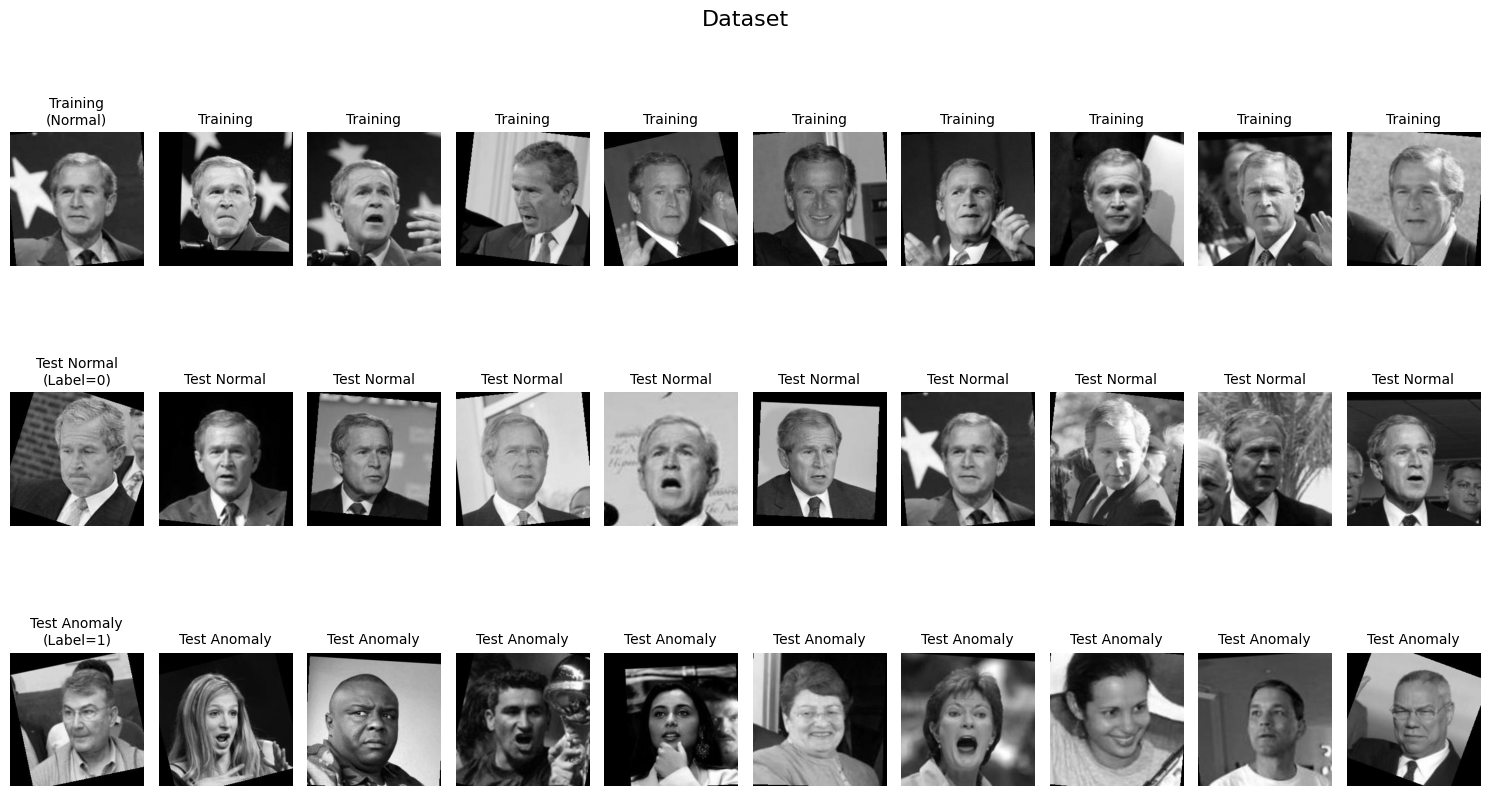

In [17]:
X_train, X_test, y_test = load_anomaly_data(seed=42)
visualize_anomaly_dataset(X_train, X_test, y_test, n_samples=10)

Autoencoder Architecture:
  Input size: 62500 features
  Bottleneck: 128 features
  Compression ratio: 488.3x
Starting training:
Total samples: 530, Batch size: 53, Batches per epoch: 10
Gradient accumulation steps: 1
Learning rate: 100, Max epochs: 100




Training:  33%|███▎      | 33/100 [24:37<49:58, 44.76s/epoch, loss=0.004380, best=0.000807, no_improve=9]  



Early stopping triggered at epoch 34
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 0.000807, total epochs: 34


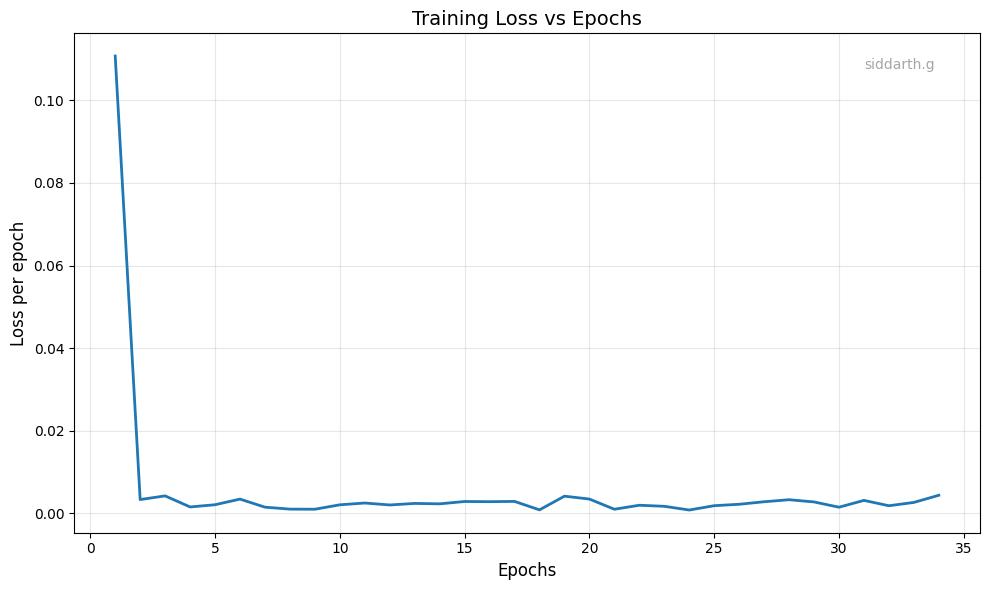

In [18]:
# Define the architecture for the autoencoder
input_size = 250 * 250
bottleneck_dim = 128   # The size of the compressed representation

# This Works
encoder_layers = [
    Linear(input_width=input_size, output_width=2500, activation='tanh'),
    Linear(input_width=2500, output_width=500, activation='tanh'),
    Linear(input_width=500, output_width=bottleneck_dim, activation='tanh')
]

decoder_layers = [
    Linear(input_width=bottleneck_dim, output_width=500, activation='tanh'),
    Linear(input_width=500, output_width=2500, activation='tanh'),
    Linear(input_width=2500, output_width=input_size, activation='sigmoid') # Output values in [0, 1]
]

# encoder_layers = [
#     Linear(input_width=input_size, output_width=512, activation='tanh'),
#     Linear(input_width=512, output_width=256, activation='tanh'),
#     Linear(input_width=256, output_width=bottleneck_dim, activation='tanh')
# ]

# decoder_layers = [
#     Linear(input_width=bottleneck_dim, output_width=256, activation='tanh'),
#     Linear(input_width=256, output_width=512, activation='tanh'),
#     Linear(input_width=512, output_width=input_size, activation='sigmoid') # Output values in [0, 1]
# ]

autoencoder = MLPAutoencoder(encoder_layers, decoder_layers, loss='mse')

print(f"Autoencoder Architecture:")
print(f"  Input size: {input_size} features")
print(f"  Bottleneck: {bottleneck_dim} features")
print(f"  Compression ratio: {input_size / bottleneck_dim:.1f}x")

# This Works
history = train_autoencoder(
    model=autoencoder,
    X_train=X_train,
    batch_size=53,
    grad_accumulation_steps=1,
    learning_rate=100,
    num_epochs=100,
    patience=10,
    relative_loss_threshold=0.01,
)

# history = train_autoencoder(
#     model=autoencoder,
#     X_train=X_train,
#     batch_size=106,
#     grad_accumulation_steps=1,
#     learning_rate=0.01,
#     num_epochs=200,
#     patience=10,
#     relative_loss_threshold=0.01,
# )

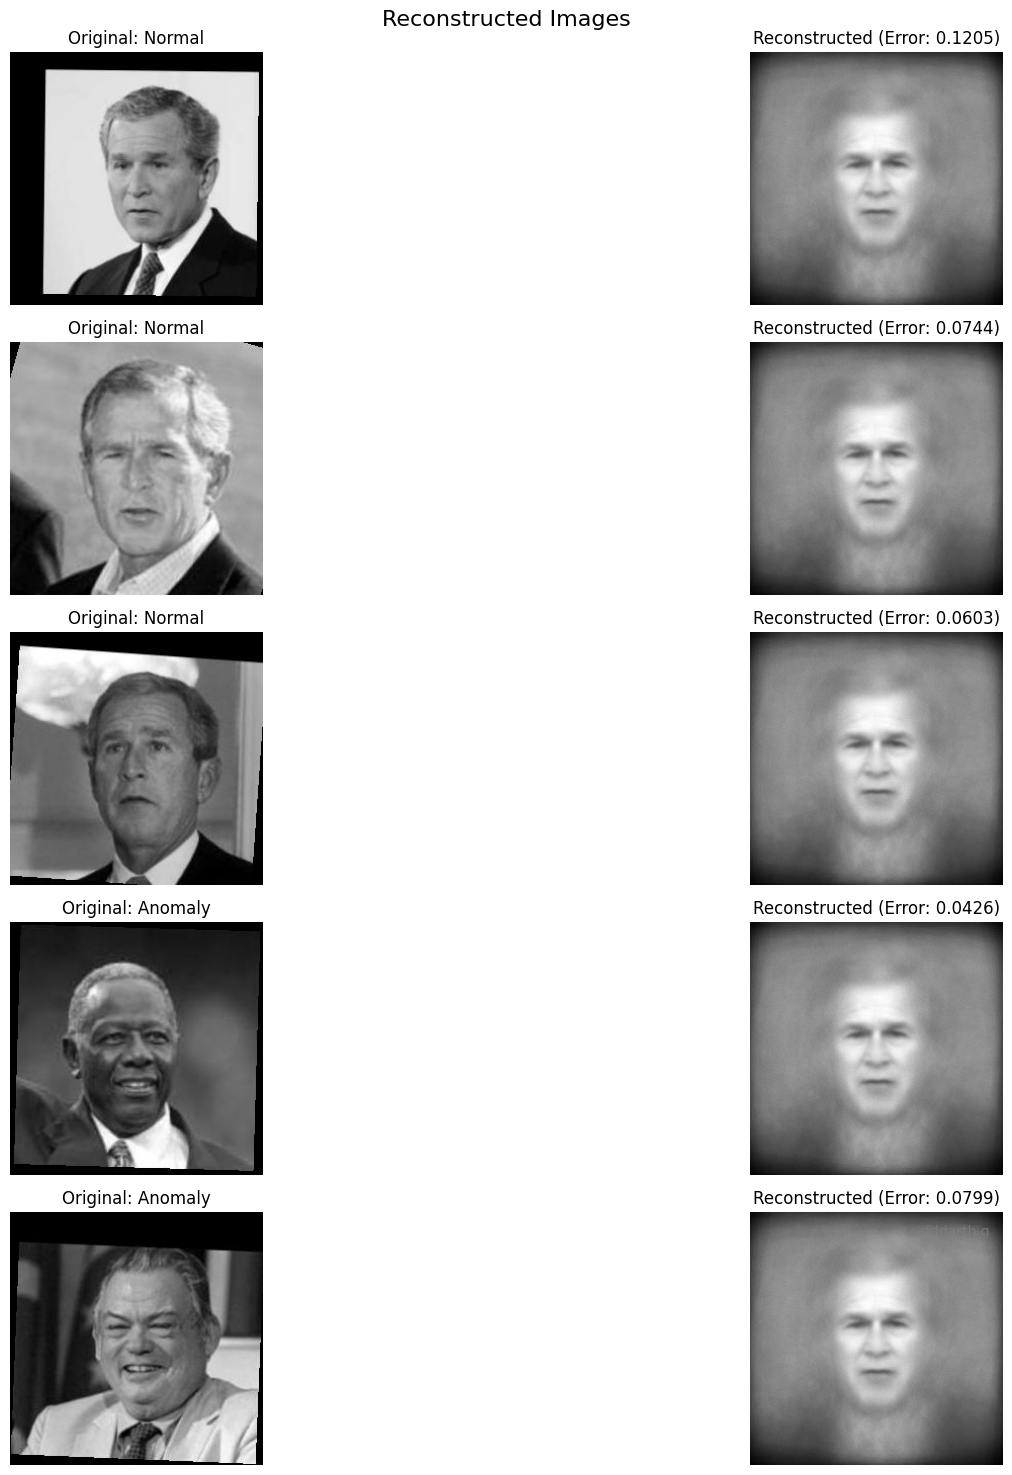

In [19]:
def visualize_faces(autoencoder, X_test, y_test=None, num_normal=5, num_anomaly=5, seed=42):
    """
    Visualizes the original and reconstructed face images from the autoencoder with proper display.
    
    Args:
        autoencoder: The trained autoencoder model
        X_test: Test data (face images)
        y_test: Test labels (0=normal/George W Bush, 1=anomaly) (optional)
        num_normal: Number of normal examples to show
        num_anomaly: Number of anomaly examples to show
        seed: Random seed for reproducibility
        
    Returns:
        fig: The matplotlib figure object
    """

    random.seed(42)
    np.random.seed(42)
    
    # LFW image dimensions
    img_height, img_width = 250, 250
    
    # If labels provided, get both normal and anomaly samples
    normal_indices = np.where(y_test == 0)[0]
    anomaly_indices = np.where(y_test == 1)[0]
    
    # Randomly sample from each class
    normal_samples = np.random.choice(normal_indices, min(num_normal, len(normal_indices)), replace=False)
    anomaly_samples = np.random.choice(anomaly_indices, min(num_anomaly, len(anomaly_indices)), replace=False)
    
    # Combine indices
    indices = np.concatenate([normal_samples, anomaly_samples])
    
    # Create labels for display
    labels = ['Normal'] * len(normal_samples) + ['Anomaly'] * len(anomaly_samples)
    
    # Determine number of rows needed
    n_samples = len(indices)
    
    # Create figure
    fig, axes = plt.subplots(n_samples, 2, figsize=(20, 3 * n_samples))
    
    # Main title
    fig.suptitle("Reconstructed Images", fontsize=16)
    
    # Plot each sample
    for i in range(n_samples):
        # Get original sample
        original = X_test[indices[i]]
        
        # Get reconstruction - need to pass as batch (add dimension)
        reconstruction = autoencoder.forward(original.reshape(1, -1))
        
        # Reshape images to 2D for display
        orig_img = original.reshape(img_height, img_width)
        recon_img = reconstruction.reshape(img_height, img_width)

        # Check how many values in [0, 0.01] are present in the original image
        # mid_range_count = np.sum((orig_img >= 0) & (orig_img <= 0.01))
        # print(f"Sample {i+1} ({labels[i]}): {mid_range_count} pixels in [0, 0.01] range")

        # Check how many values in [0.25, 0.75] are present in the reconstructed image
        # mid_range_count = np.sum((recon_img >= 0.25) & (recon_img <= 0.75))
        # print(f"Sample {i+1} ({labels[i]}): {mid_range_count} pixels in [0.25, 0.75] range")
        
        # Calculate pixel-wise error map
        error_map = np.abs(orig_img - recon_img)
        
        # Calculate reconstruction error (MSE)
        error = np.mean((original - reconstruction.flatten())**2)
        
        # Original
        axes[i, 0].imshow(orig_img, cmap='gray')
        if labels[i]:
            axes[i, 0].set_title(f"Original: {labels[i]}")
        else:
            axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')
        
        # Reconstructed
        axes[i, 1].imshow(recon_img, cmap='gray')
        axes[i, 1].set_title(f"Reconstructed (Error: {error:.4f})")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    add_username("siddarth.g")
    plt.show()

visualize_faces(autoencoder, X_test, y_test, num_normal=3, num_anomaly=2)

In [20]:
def calculate_reconstruction_errors(autoencoder, X_test):
    """
    Calculate reconstruction error (MSE) for each test image.
    
    Args:
        autoencoder: Trained autoencoder model
        X_test: Test images, shape (n_samples, n_features)
        batch_size: Number of images to process at once (default=256)
    
    Returns:
        reconstruction_errors: MSE for each image, shape (n_samples,)
    """
    print(f"Calculating reconstruction errors...")
    
    n_samples = X_test.shape[0]
    reconstruction_errors = np.zeros(n_samples)
    
    # Get reconstructions for this batch
    batch_reconstructed = autoencoder.forward(X_test)

    # Calculate MSE for each image in batch
    batch_errors = np.mean((X_test - batch_reconstructed) ** 2, axis=1)
    reconstruction_errors = batch_errors
    
    print(f"Reconstruction errors calculated for {len(X_test)} images")
    print(f"  Min error: {reconstruction_errors.min():.6f}")
    print(f"  Max error: {reconstruction_errors.max():.6f}")
    print(f"  Mean error: {reconstruction_errors.mean():.6f}")
    
    return reconstruction_errors

def find_optimal_threshold(reconstruction_errors, y_test, method='youden'):
    """
    Find optimal threshold for anomaly classification.
    
    Args:
        reconstruction_errors: Reconstruction errors for test set
        y_test: True labels (0=normal, 1=anomaly)
        method: 'youden' (Youden's J statistic) or 'percentile'
    
    Returns:
        optimal_threshold: Threshold value
    """
    if method == 'youden':
        # Use Youden's J statistic (maximizes TPR - FPR)
        fpr, tpr, thresholds = roc_curve(y_test, reconstruction_errors)
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        optimal_threshold = thresholds[optimal_idx]
        
        print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.6f}")
        print(f"  TPR at threshold: {tpr[optimal_idx]:.3f}")
        print(f"  FPR at threshold: {fpr[optimal_idx]:.3f}")
        
    elif method == 'percentile':
        # Use 95th percentile of normal class errors
        normal_errors = reconstruction_errors[y_test == 0]
        optimal_threshold = np.percentile(normal_errors, 95)
        
        print(f"\nOptimal threshold (95th percentile): {optimal_threshold:.6f}")
    
    return optimal_threshold

def evaluate_anomaly_detection(reconstruction_errors, y_test, threshold):
    """
    Evaluate anomaly detection performance using reconstruction errors.
    
    Args:
        reconstruction_errors: Reconstruction errors for test set
        y_test: True labels (0=normal, 1=anomaly)
        threshold: Classification threshold
    
    Returns:
        metrics: Dictionary containing all evaluation metrics
    """
    y_pred = (reconstruction_errors > threshold).astype(int)
    
    # Calculate metrics
    auc_score = roc_auc_score(y_test, reconstruction_errors)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Store results
    metrics = {
        'auc_score': auc_score,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'threshold': threshold,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'y_pred': y_pred
    }
    
    return metrics

def print_evaluation_report(metrics):
    """
    Print a formatted evaluation report.
    
    Args:
        metrics: Dictionary containing evaluation metrics
    """
    print_separator()
    print(f"ANOMALY DETECTION EVALUATION REPORT")
    print(f"\nClassification Threshold: {metrics['threshold']:.6f}")
    print(f"\n{'Metric':<20} {'Value':<10}")
    print(f"{'AUC Score':<20} {metrics['auc_score']:.4f}")
    print(f"{'Precision':<20} {metrics['precision']:.4f}")
    print(f"{'Recall':<20} {metrics['recall']:.4f}")
    print(f"{'F1-Score':<20} {metrics['f1_score']:.4f}")
    
    print(f"\n{'Confusion Matrix':<20}")
    print(f"{'True Positives':<20} {metrics['true_positives']:<10}")
    print(f"{'False Positives':<20} {metrics['false_positives']:<10}")
    print(f"{'True Negatives':<20} {metrics['true_negatives']:<10}")
    print(f"{'False Negatives':<20} {metrics['false_negatives']:<10}")
    print_separator()

def plot_error_distributions(reconstruction_errors, y_test, threshold):
    """
    Plot reconstruction error distributions for normal vs anomaly classes.
    
    Args:
        reconstruction_errors: Reconstruction errors for test set
        y_test: True labels (0=normal, 1=anomaly)
        threshold: Classification threshold
    """
    normal_errors = reconstruction_errors[y_test == 0]
    anomaly_errors = reconstruction_errors[y_test == 1]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    ax1.hist(normal_errors, bins=50, alpha=0.7, label='Normal (George W Bush)', color='yellow', edgecolor='black')
    ax1.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly (Others)', color='red', edgecolor='black')
    ax1.axvline(threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
    ax1.set_xlabel('Reconstruction MSE', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Reconstruction Error', fontsize=14)
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Box plot
    data_to_plot = [normal_errors, anomaly_errors]
    bp = ax2.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)
    bp['boxes'][0].set_facecolor('yellow')
    bp['boxes'][1].set_facecolor('red')
    ax2.axhline(threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
    ax2.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
    ax2.set_title('Reconstruction Error', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')
    
    plt.suptitle('Anomaly Detection: Error Analysis', fontsize=16)
    plt.tight_layout()
    add_username("siddarth.g")
    
    plt.show()

def plot_roc_curve(reconstruction_errors, y_test, metrics):
    """
    Plot ROC curve for anomaly detection.
    
    Args:
        reconstruction_errors: Reconstruction errors for test set
        y_test: True labels (0=normal, 1=anomaly)
        metrics: Dictionary containing evaluation metrics
    """
    fpr, tpr, thresholds = roc_curve(y_test, reconstruction_errors)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {metrics["auc_score"]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    
    # Mark optimal threshold point
    threshold_idx = np.argmin(np.abs(thresholds - metrics['threshold']))
    plt.scatter(fpr[threshold_idx], tpr[threshold_idx], color='green', s=50, zorder=5, label=f'Threshold = {metrics["threshold"]:.4f}')
    
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14)
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    add_username("siddarth.g")
    plt.tight_layout()
    plt.show()

Calculating reconstruction errors...
Reconstruction errors calculated for 200 images
  Min error: 0.013476
  Max error: 0.174078
  Mean error: 0.065816

Optimal threshold (Youden's J): 0.056017
  TPR at threshold: 0.720
  FPR at threshold: 0.470


ANOMALY DETECTION EVALUATION REPORT

Classification Threshold: 0.056017

Metric               Value     
AUC Score            0.6383
Precision            0.6017
Recall               0.7100
F1-Score             0.6514

Confusion Matrix    
True Positives       71        
False Positives      47        
True Negatives       53        
False Negatives      29        




C:\Users\sidda\AppData\Local\Temp\ipykernel_22892\3747377120.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)


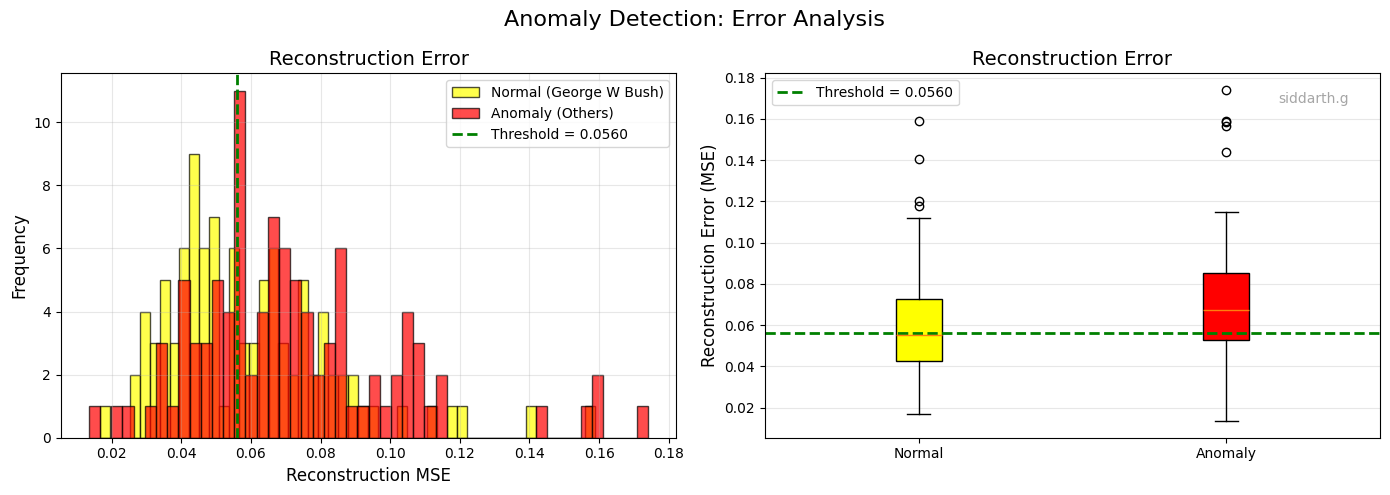

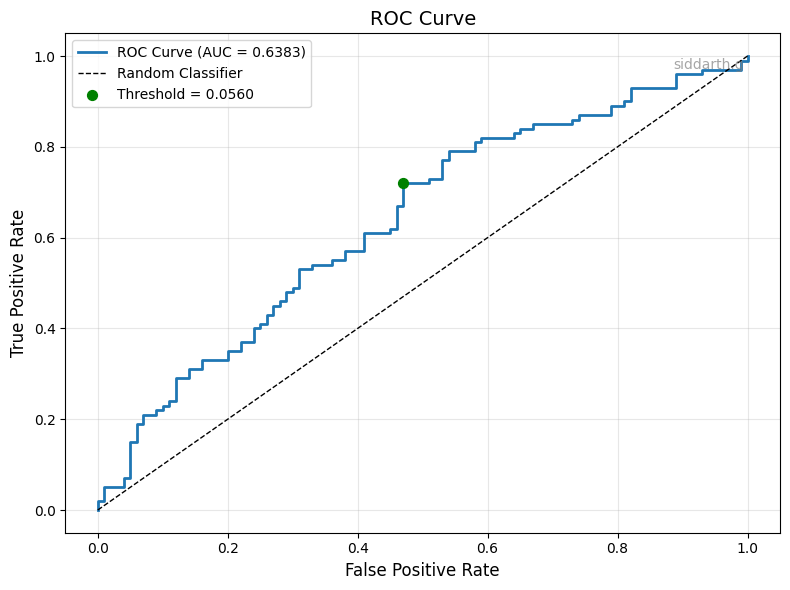

Metrics saved for further analysis:
  - AUC: 0.6383
  - F1-Score: 0.6514


In [58]:
reconstruction_errors = calculate_reconstruction_errors(autoencoder, X_test)
threshold = find_optimal_threshold(reconstruction_errors, y_test, method='youden')
metrics = evaluate_anomaly_detection(reconstruction_errors, y_test, threshold)

history['bottleneck_dim'] = 128
history['auc_score'] = metrics['auc_score']
history['f1_score'] = metrics['f1_score']
history['reconstruction_errors'] = reconstruction_errors
history['recall'] = metrics['recall']
history['precision'] = metrics['precision']
history['tp'] = metrics['true_positives']
history['fp'] = metrics['false_positives']
history['tn'] = metrics['true_negatives']
history['fn'] = metrics['false_negatives']

print_evaluation_report(metrics)
plot_error_distributions(reconstruction_errors, y_test, threshold)
plot_roc_curve(reconstruction_errors, y_test, metrics)
print(f"Metrics saved for further analysis:")
print(f"  - AUC: {metrics['auc_score']:.4f}")
print(f"  - F1-Score: {metrics['f1_score']:.4f}")

### Question 3.2.2 : Analysis and Visualization

In [ ]:
# Function to create an autoencoder with a specified bottleneck dimension
def create_autoencoder_with_bottleneck(input_size, bottleneck_dim):
    """
    Create an autoencoder with specified bottleneck dimension.
    Keeps the same architecture, only changes bottleneck size.
    
    Args:
        input_size: Input feature dimension
        bottleneck_dim: Bottleneck (latent) dimension
    
    Returns:
        autoencoder: MLPAutoencoder instance
    """
    encoder_layers = [
    Linear(input_width=input_size, output_width=2500, activation='tanh'),
        Linear(input_width=2500, output_width=500, activation='tanh'),
        Linear(input_width=500, output_width=bottleneck_dim, activation='tanh')
    ]

    decoder_layers = [
        Linear(input_width=bottleneck_dim, output_width=500, activation='tanh'),
        Linear(input_width=500, output_width=2500, activation='tanh'),
        Linear(input_width=2500, output_width=input_size, activation='sigmoid') # Output values in [0, 1]
    ]
    
    # Create autoencoder
    autoencoder = MLPAutoencoder(encoder_layers, decoder_layers, loss='mse')
    
    return autoencoder

def train_and_evaluate_bottleneck(bottleneck_dim, X_train, X_test, y_test, input_size, seed=42):
    """
    Train autoencoder with given bottleneck dimension and evaluate its performance.
    
    Args:
        bottleneck_dim: Bottleneck dimension to test
        X_train: Training data (normal class only)
        X_test: Test data (normal + anomalies)
        y_test: Test labels (0=normal, 1=anomaly)
        input_size: Input feature dimension
        seed: Random seed
        verbose: Whether to print detailed progress
    
    Returns:
        results: Dictionary containing all evaluation metrics and data
    """
    print_separator()
    print(f"Training autoencoder with bottleneck dimension: {bottleneck_dim}")
    
    # Create autoencoder
    autoencoder = create_autoencoder_with_bottleneck(input_size, bottleneck_dim)
    
    # Train autoencoder
    print(f"\nTraining autoencoder...")
    history = train_autoencoder(
    model=autoencoder,
    X_train=X_train,
    batch_size=106,
    grad_accumulation_steps=1,
    learning_rate=5,
    num_epochs=75,
    patience=10,
    relative_loss_threshold=0.01,
    )
    
    # Calculate reconstruction errors
    print(f"\nEvaluating on test set...")
    reconstruction_errors = calculate_reconstruction_errors(autoencoder, X_test)
    
    # Find optimal threshold
    threshold = find_optimal_threshold(reconstruction_errors, y_test, method='youden')
    
    # Evaluate performance
    metrics = evaluate_anomaly_detection(reconstruction_errors, y_test, threshold)
    
    # Print results
    print_evaluation_report(metrics)
    
    # Store results
    results = {
        'bottleneck_dim': bottleneck_dim,
        'autoencoder': autoencoder,
        'training_loss': history['final_loss'],
        'reconstruction_errors': reconstruction_errors,
        'threshold': threshold,
        'auc_score': metrics['auc_score'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'tp': metrics['true_positives'],
        'fp': metrics['false_positives'],
        'tn': metrics['true_negatives'],
        'fn': metrics['false_negatives']
    }
    
    return results

def compare_bottleneck_dimensions(bottleneck_dims, X_train, X_test, y_test, input_size, seed=42, old=None):
    """
    Train and evaluate autoencoders with different bottleneck dimensions.
    
    Args:
        bottleneck_dims: List of bottleneck dimensions to test
        X_train: Training data
        X_test: Test data
        y_test: Test labels
        input_size: Input feature dimension
        seed: Random seed
        old: Previous training history

    Returns:
        all_results: List of result dictionaries for each bottleneck dimension
    """
    all_results = []
    
    print_separator()
    print(f"BOTTLENECK DIMENSION ANALYSIS")
    print(f"Testing dimensions: {bottleneck_dims}")
    
    for bottleneck_dim in bottleneck_dims:
        results = train_and_evaluate_bottleneck(
            bottleneck_dim=bottleneck_dim,
            X_train=X_train,
            X_test=X_test,
            y_test=y_test,
            input_size=input_size,
            seed=seed
        )
        all_results.append(results)
    
    if old is not None:
        all_results.append(old)

    return all_results


In [68]:
def plot_bottleneck_comparison(all_results):
    """
    Plot comparison of different bottleneck dimensions.
    
    Args:
        all_results: List of result dictionaries from compare_bottleneck_dimensions
    """
    bottleneck_dims = [r['bottleneck_dim'] for r in all_results]
    auc_scores = [r['auc_score'] for r in all_results]
    f1_scores = [r['f1_score'] for r in all_results]
    precisions = [r['precision'] for r in all_results]
    recalls = [r['recall'] for r in all_results]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: AUC vs Bottleneck Dimension
    axes[0, 0].plot(bottleneck_dims, auc_scores, 'o-', linewidth=2, markersize=8, color='red')
    axes[0, 0].set_xlabel('Bottleneck Dimension', fontsize=11)
    axes[0, 0].set_ylabel('AUC Score', fontsize=11)
    axes[0, 0].set_title('AUC Score vs Bottleneck', fontsize=12)
    axes[0, 0].grid(alpha=0.3)
    # axes[0, 0].set_ylim([0.75, 1.0])
    
    # Plot 2: F1, Precision, Recall vs Bottleneck Dimension
    axes[0, 1].plot(bottleneck_dims, f1_scores, 'o-', linewidth=2, markersize=8, label='F1-Score', color='orange')
    axes[0, 1].plot(bottleneck_dims, precisions, 's-', linewidth=2, markersize=8, label='Precision', color='green')
    axes[0, 1].plot(bottleneck_dims, recalls, '^-', linewidth=2, markersize=8, label='Recall', color='blue')
    axes[0, 1].set_xlabel('Bottleneck Dimension', fontsize=11)
    axes[0, 1].set_ylabel('Score', fontsize=11)
    axes[0, 1].set_title('Performance vs Bottleneck', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    # axes[0, 1].set_ylim([0.7, 1.0])
    
    # Plot 4: Summary Table
    axes[1, 0].axis('off')
    table_data = []
    for r in all_results:
        table_data.append([
            r['bottleneck_dim'],
            f"{r['auc_score']:.4f}",
            f"{r['f1_score']:.4f}",
            f"{r['precision']:.4f}",
            f"{r['recall']:.4f}"
        ])
    
    table = axes[1, 0].table(
        cellText=table_data,
        colLabels=['Bottleneck', 'AUC', 'F1', 'Precision', 'Recall'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header
    for i in range(5):
        table[(0, i)].set_text_props(weight='bold', color='black')
    
    axes[1, 0].set_title('Performance Summary', fontsize=12)

    axes[1, 1].axis('off')

    plt.suptitle('Bottleneck Dimension Analysis', fontsize=16)
    plt.tight_layout()
    
    add_username("siddarth.g")
    plt.show()

In [61]:
def plot_roc_curves_comparison(all_results, y_test):
    """
    Plot ROC curves for all bottleneck dimensions on a single graph.
    
    Args:
        all_results: List of result dictionaries
        y_test: True test labels
    """
    plt.figure(figsize=(10, 8))
    
    colors = ['purple', 'red', 'blue', 'green', 'orange']
    
    for i, results in enumerate(all_results):
        reconstruction_errors = results['reconstruction_errors']
        fpr, tpr, _ = roc_curve(y_test, reconstruction_errors)
        auc_score = results['auc_score']
        bottleneck_dim = results['bottleneck_dim']
        
        plt.plot(fpr, tpr, linewidth=2.5, label=f'Bottleneck={bottleneck_dim} (AUC={auc_score:.4f})', color=colors[i % len(colors)])
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    
    plt.xlabel('FPR', fontsize=12)
    plt.ylabel('TPR', fontsize=12)
    plt.title('ROC Curves', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    add_username("siddarth.g")
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Define bottleneck dimensions to test
bottleneck_dimensions = [64, 256] 

# Get input size from data
input_size = X_train.shape[1]

print(f"Input size: {input_size}")
print(f"Testing bottleneck dimensions: {bottleneck_dimensions}")

# Run comparison
all_results = compare_bottleneck_dimensions(
    bottleneck_dims=bottleneck_dimensions,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    input_size=input_size,
    seed=42,
    old=history
)

In [76]:
def comprehensive_visualization(autoencoder, X_test, y_test, reconstruction_errors, 
                                threshold, y_pred, img_shape=(125, 94)):
    """
    Complete visualization pipeline for anomaly detection results.
    
    Args:
        autoencoder: Trained autoencoder model
        X_test: Test images
        y_test: True labels
        reconstruction_errors: Reconstruction errors
        threshold: Classification threshold
        y_pred: Predicted labels
        img_shape: Image dimensions (height, width)
    """
    print_separator()
    print(f"COMPREHENSIVE VISUALIZATION")
    
    # Find classification examples
    print("Finding classification examples...")
    examples = find_classification_examples(X_test, y_test, y_pred, 
                                           reconstruction_errors, img_shape)

    # Visualize classification examples
    print("Visualizing classification examples...")
    visualize_classification_examples(autoencoder, X_test, examples, 
                                     threshold, img_shape)

    # Plot Precision-Recall curve
    print("Plotting Precision-Recall curve...")
    avg_precision, pr_auc = plot_precision_recall_curve(reconstruction_errors, 
                                                        y_test, threshold)

    print(f"PR Curve Metrics:")
    print(f"  Average Precision: {avg_precision:.4f}")
    print(f"  PR-AUC: {pr_auc:.4f}")
    
    return examples, avg_precision, pr_auc

In [62]:
# Sort elements of all_results by bottleneck_dim
all_results = sorted(all_results, key=lambda x: x['bottleneck_dim'])

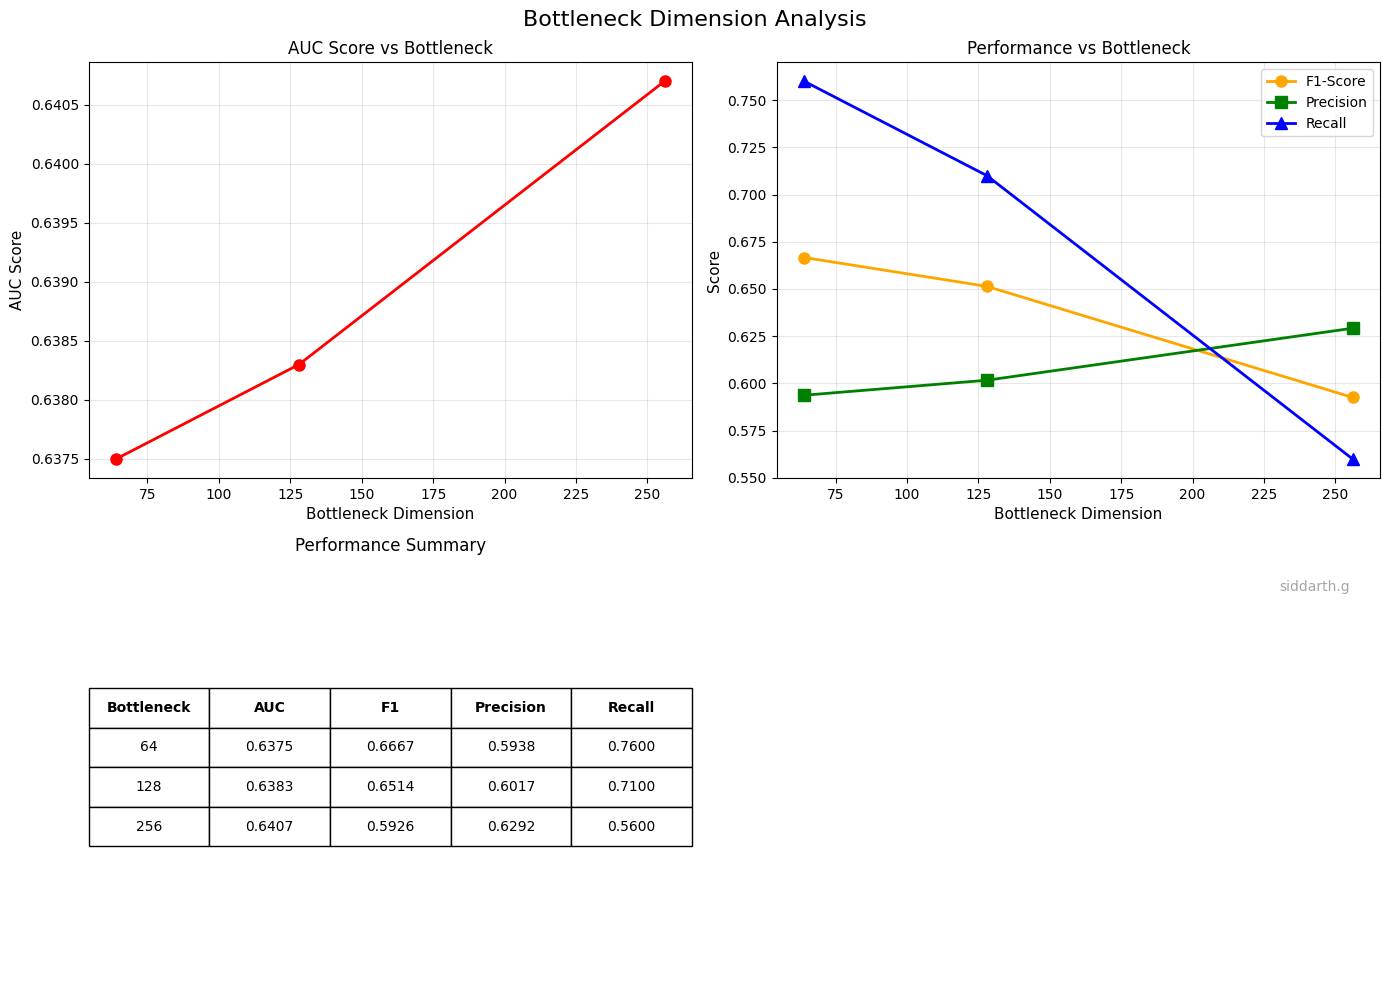

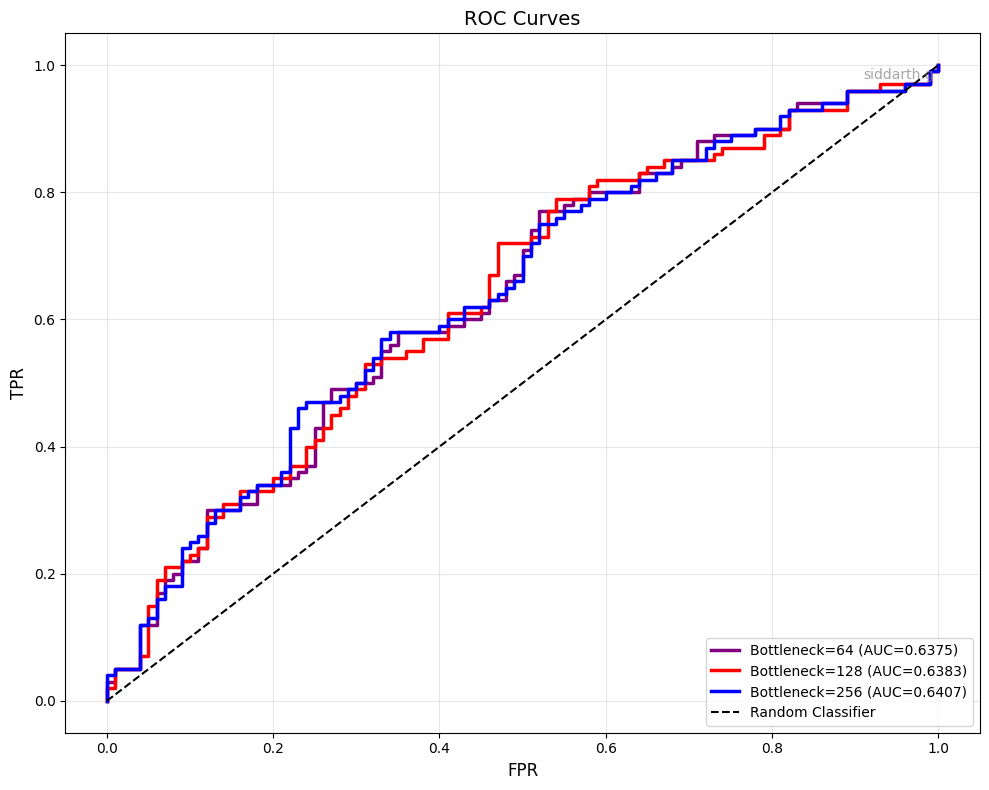



FINAL SUMMARY

Bottleneck Dimension: 64
  AUC Score: 0.6375
  F1-Score: 0.6667

Bottleneck Dimension: 128
  AUC Score: 0.6383
  F1-Score: 0.6514

Bottleneck Dimension: 256
  AUC Score: 0.6407
  F1-Score: 0.5926


In [69]:
plot_bottleneck_comparison(all_results)
plot_roc_curves_comparison(all_results, y_test)

# Print final summary
print_separator()
print(f"FINAL SUMMARY")
for results in all_results:
    print(f"\nBottleneck Dimension: {results['bottleneck_dim']}")
    print(f"  AUC Score: {results['auc_score']:.4f}")
    print(f"  F1-Score: {results['f1_score']:.4f}")

In [70]:
def find_classification_examples(X_test, y_test, y_pred, reconstruction_errors, img_shape):
    """
    Find examples of each classification type.
    
    Args:
        X_test: Test images
        y_test: True labels (0=normal, 1=anomaly)
        y_pred: Predicted labels (0=normal, 1=anomaly)
        reconstruction_errors: Reconstruction error for each image
        img_shape: Tuple (height, width) for reshaping images
    
    Returns:
        examples: Dictionary with indices for TN, TP, FP, FN
    """
    # True Negative: Predicted normal (0), Actually normal (0)
    tn_indices = np.where((y_pred == 0) & (y_test == 0))[0]
    
    # True Positive: Predicted anomaly (1), Actually anomaly (1)
    tp_indices = np.where((y_pred == 1) & (y_test == 1))[0]
    
    # False Positive: Predicted anomaly (1), Actually normal (0)
    fp_indices = np.where((y_pred == 1) & (y_test == 0))[0]
    
    # False Negative: Predicted normal (0), Actually anomaly (1)
    fn_indices = np.where((y_pred == 0) & (y_test == 1))[0]
    
    examples = {
        'TN': tn_indices[0] if len(tn_indices) > 0 else None,
        'TP': tp_indices[0] if len(tp_indices) > 0 else None,
        'FP': fp_indices[0] if len(fp_indices) > 0 else None,
        'FN': fn_indices[0] if len(fn_indices) > 0 else None,
        'TN_error': reconstruction_errors[tn_indices[0]] if len(tn_indices) > 0 else None,
        'TP_error': reconstruction_errors[tp_indices[0]] if len(tp_indices) > 0 else None,
        'FP_error': reconstruction_errors[fp_indices[0]] if len(fp_indices) > 0 else None,
        'FN_error': reconstruction_errors[fn_indices[0]] if len(fn_indices) > 0 else None,
    }
    
    print(f"Found examples:")
    print(f"  True Negatives: {len(tn_indices)}")
    print(f"  True Positives: {len(tp_indices)}")
    print(f"  False Positives: {len(fp_indices)}")
    print(f"  False Negatives: {len(fn_indices)}")
    
    return examples

In [71]:
def visualize_classification_examples(autoencoder, X_test, examples, threshold, img_shape):
    """
    Visualize examples of all classification types.
    
    Args:
        autoencoder: Trained autoencoder model
        X_test: Test images
        examples: Dictionary with indices for each classification type
        threshold: Classification threshold
        img_shape: Tuple (height, width) for reshaping images
    """
    fig = plt.figure(figsize=(16, 10))
    
    # Define layout: 4 rows (TN, TP, FP, FN) x 3 columns (Original, Reconstruction, Error Map)
    categories = [
        ('TN', 'True Negative\n(Correctly Identified Normal)', 'red'),
        ('TP', 'True Positive\n(Correctly Identified Anomaly)', 'red'),
        ('FP', 'False Positive\n(Normal Misclassified as Anomaly)', 'green'),
        ('FN', 'False Negative\n(Anomaly Misclassified as Normal)', 'green')
    ]
    
    for row, (cat_key, cat_name, color) in enumerate(categories):
        idx = examples[cat_key]
        error = examples[f'{cat_key}_error']
        
        if idx is None:
            continue
        
        # Get original and reconstruction
        original = X_test[idx].reshape(img_shape)
        reconstructed = autoencoder.forward(X_test[idx:idx+1]).reshape(img_shape)
        
        # Calculate pixel-wise error map
        error_map = np.abs(original - reconstructed)
        
        # Column 1: Original Image
        ax1 = plt.subplot(4, 3, row * 3 + 1)
        ax1.imshow(original, cmap='gray')
        ax1.set_title(f'{cat_name}\nOriginal', fontsize=10, color=color)
        ax1.axis('off')
        
        # Column 2: Reconstruction
        ax2 = plt.subplot(4, 3, row * 3 + 2)
        ax2.imshow(reconstructed, cmap='gray')
        ax2.set_title(f'Reconstruction\nError: {error:.6f}', fontsize=10)
        ax2.axis('off')
        
        # Column 3: Error Map
        ax3 = plt.subplot(4, 3, row * 3 + 3)
        im = ax3.imshow(error_map, cmap='hot')
        ax3.set_title(f'Error Map\n(Threshold: {threshold:.6f})', fontsize=10)
        ax3.axis('off')
        plt.colorbar(im, ax=ax3, fraction=0.046)
    
    plt.suptitle('Classification', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    add_username("siddarth.g")
    
    plt.show()


In [72]:
def plot_precision_recall_curve(reconstruction_errors, y_test, threshold=None):
    """
    Plot Precision-Recall curve.
    
    Args:
        reconstruction_errors: Reconstruction errors for test set
        y_test: True labels (0=normal, 1=anomaly)
        threshold: Optional threshold to mark on the curve
    """
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, reconstruction_errors)
    
    # Calculate Average Precision (area under PR curve)
    avg_precision = average_precision_score(y_test, reconstruction_errors)
    
    # Calculate PR-AUC (area under curve)
    pr_auc = auc(recall, precision)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.plot(recall, precision, linewidth=2.5, color='blue', label=f'PR Curve (AP={avg_precision:.4f}, AUC={pr_auc:.4f})')
    
    # Mark threshold point if provided
    if threshold is not None:
        # Find the point on the curve closest to the threshold
        threshold_idx = np.argmin(np.abs(thresholds - threshold))
        ax.scatter(recall[threshold_idx], precision[threshold_idx], color='red', s=200, zorder=5, marker='*', label=f'Threshold={threshold:.4f}')
    
    # Baseline (random classifier)
    baseline = np.sum(y_test == 1) / len(y_test)  # Proportion of anomalies
    ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, label=f'Random Classifier (baseline={baseline:.3f})')
    
    ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curve - Anomaly Detection', fontsize=14)
    ax.legend(loc='lower left', fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    add_username("siddarth.g")
    
    plt.tight_layout()
    plt.show()
    
    return avg_precision, pr_auc

In [73]:
def create_detailed_comparison_grid(autoencoder, X_test, y_test, reconstruction_errors, threshold, y_pred, img_shape=(250, 250), n_examples=3):
    """
    Create a detailed grid showing multiple examples of each classification type.
    
    Args:
        autoencoder: Trained autoencoder
        X_test: Test images
        y_test: True labels
        reconstruction_errors: Reconstruction errors
        threshold: Classification threshold
        y_pred: Predicted labels
        img_shape: Image dimensions
        n_examples: Number of examples per category
    """
    # Get indices for each category
    tn_indices = np.where((y_pred == 0) & (y_test == 0))[0][:n_examples]
    tp_indices = np.where((y_pred == 1) & (y_test == 1))[0][:n_examples]
    fp_indices = np.where((y_pred == 1) & (y_test == 0))[0][:n_examples]
    fn_indices = np.where((y_pred == 0) & (y_test == 1))[0][:n_examples]
    
    fig, axes = plt.subplots(4, n_examples * 2, figsize=(16, 10))
    
    categories = [
        (tn_indices, 'True Negative', 'red'),
        (tp_indices, 'True Positive', 'red'),
        (fp_indices, 'False Positive', 'green'),
        (fn_indices, 'False Negative', 'green')
    ]
    
    for row, (indices, cat_name, color) in enumerate(categories):
        for col, idx in enumerate(indices):
            # Original
            ax_orig = axes[row, col * 2]
            ax_orig.imshow(X_test[idx].reshape(img_shape), cmap='gray')
            ax_orig.axis('off')
            if col == 0:
                ax_orig.set_title(f'{cat_name}\nOriginal', fontsize=9, color=color)
            else:
                ax_orig.set_title('Original', fontsize=9)
            
            # Reconstruction
            ax_recon = axes[row, col * 2 + 1]
            reconstructed = autoencoder.forward(X_test[idx:idx+1]).reshape(img_shape)
            ax_recon.imshow(reconstructed, cmap='gray')
            ax_recon.axis('off')
            error = reconstruction_errors[idx]
            ax_recon.set_title(f'Recon\nErr:{error:.4f}', fontsize=9)
    
    plt.suptitle(f'Classification Examples Grid (Threshold={threshold:.4f})', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    add_username("siddarth.g")
    
    plt.show()

In [79]:
best_result = all_results[2] # Can be changed
best_autoencoder = best_result['autoencoder']
best_threshold = best_result['threshold']
best_reconstruction_errors = best_result['reconstruction_errors']

# Get predictions
y_pred = (best_reconstruction_errors > best_threshold).astype(int)

# Image shape for LFW
img_shape = (250, 250)  # height, width



COMPREHENSIVE VISUALIZATION
Finding classification examples...
Found examples:
  True Negatives: 67
  True Positives: 56
  False Positives: 33
  False Negatives: 44
Visualizing classification examples...


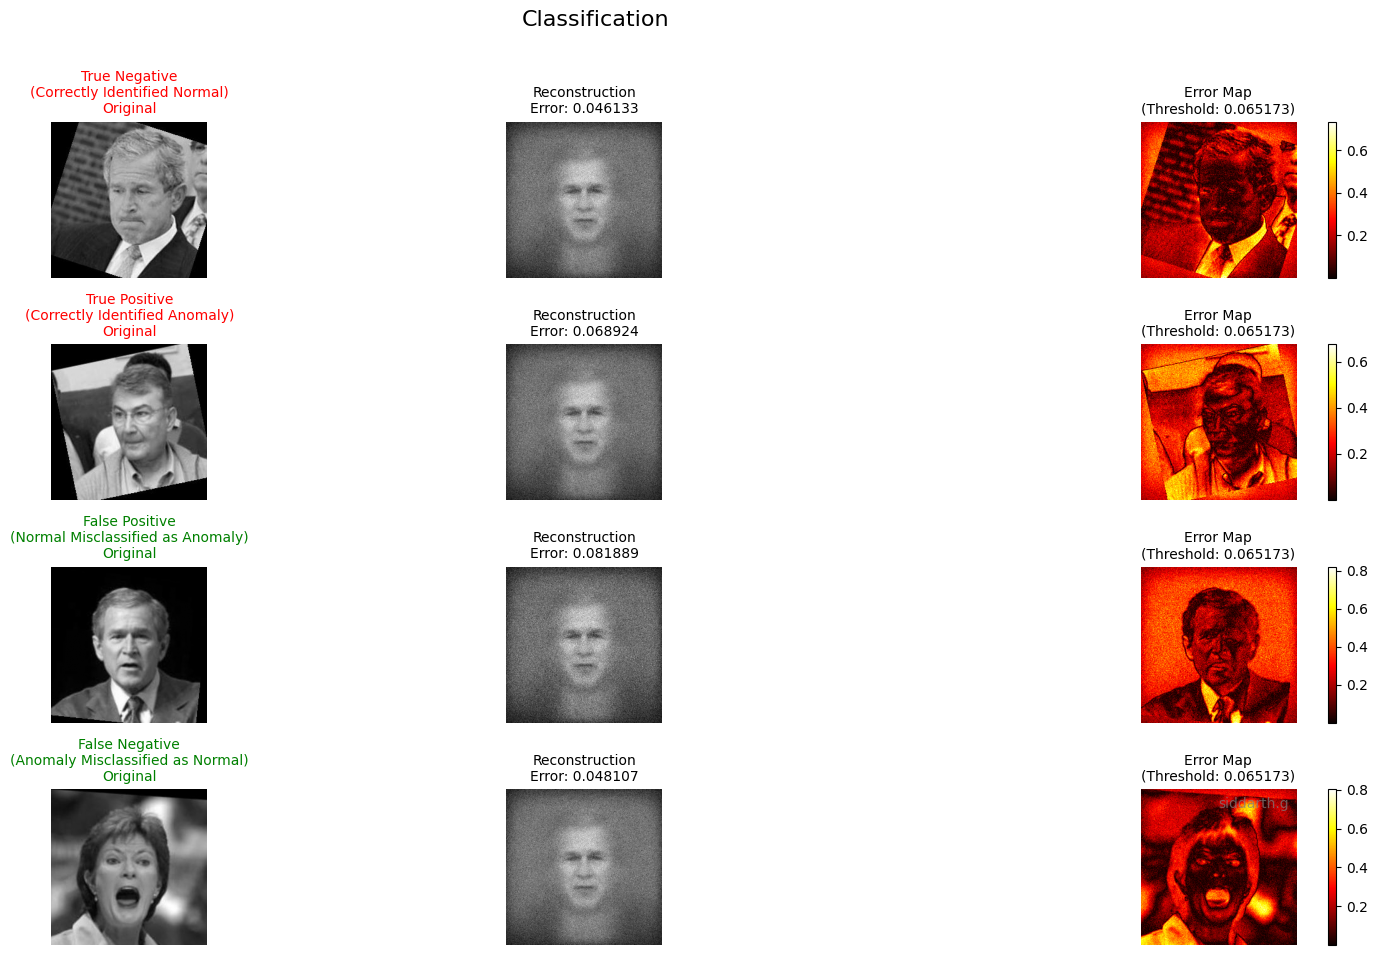

Plotting Precision-Recall curve...


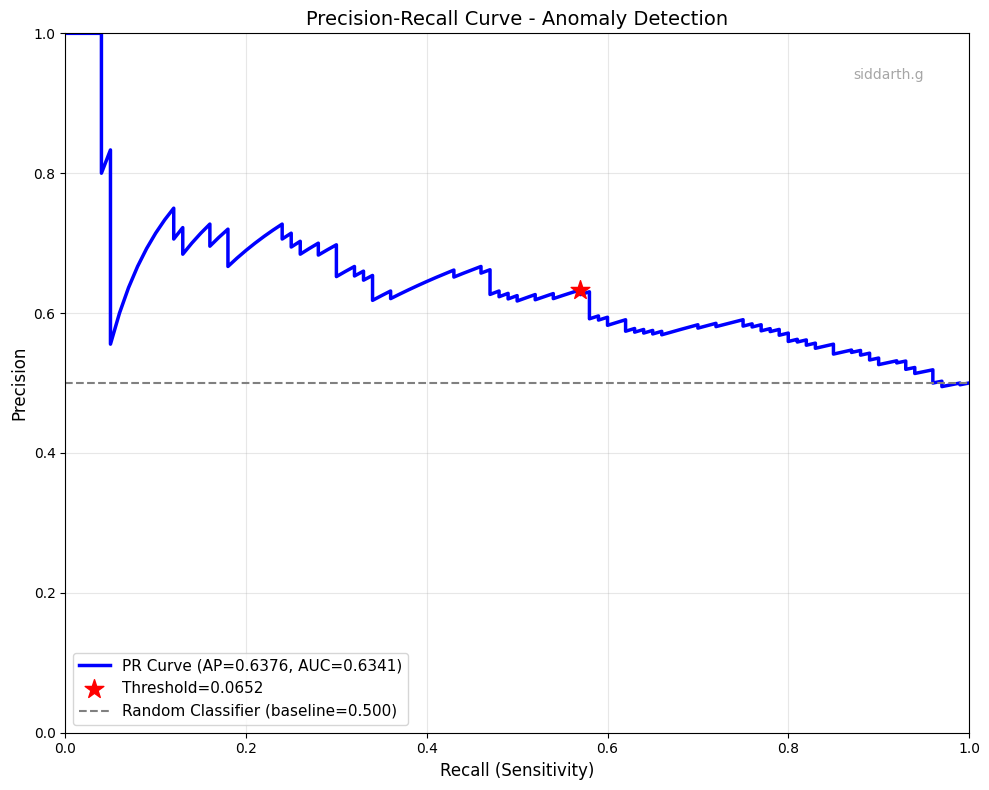

PR Curve Metrics:
  Average Precision: 0.6376
  PR-AUC: 0.6341

Creating detailed comparison grid...


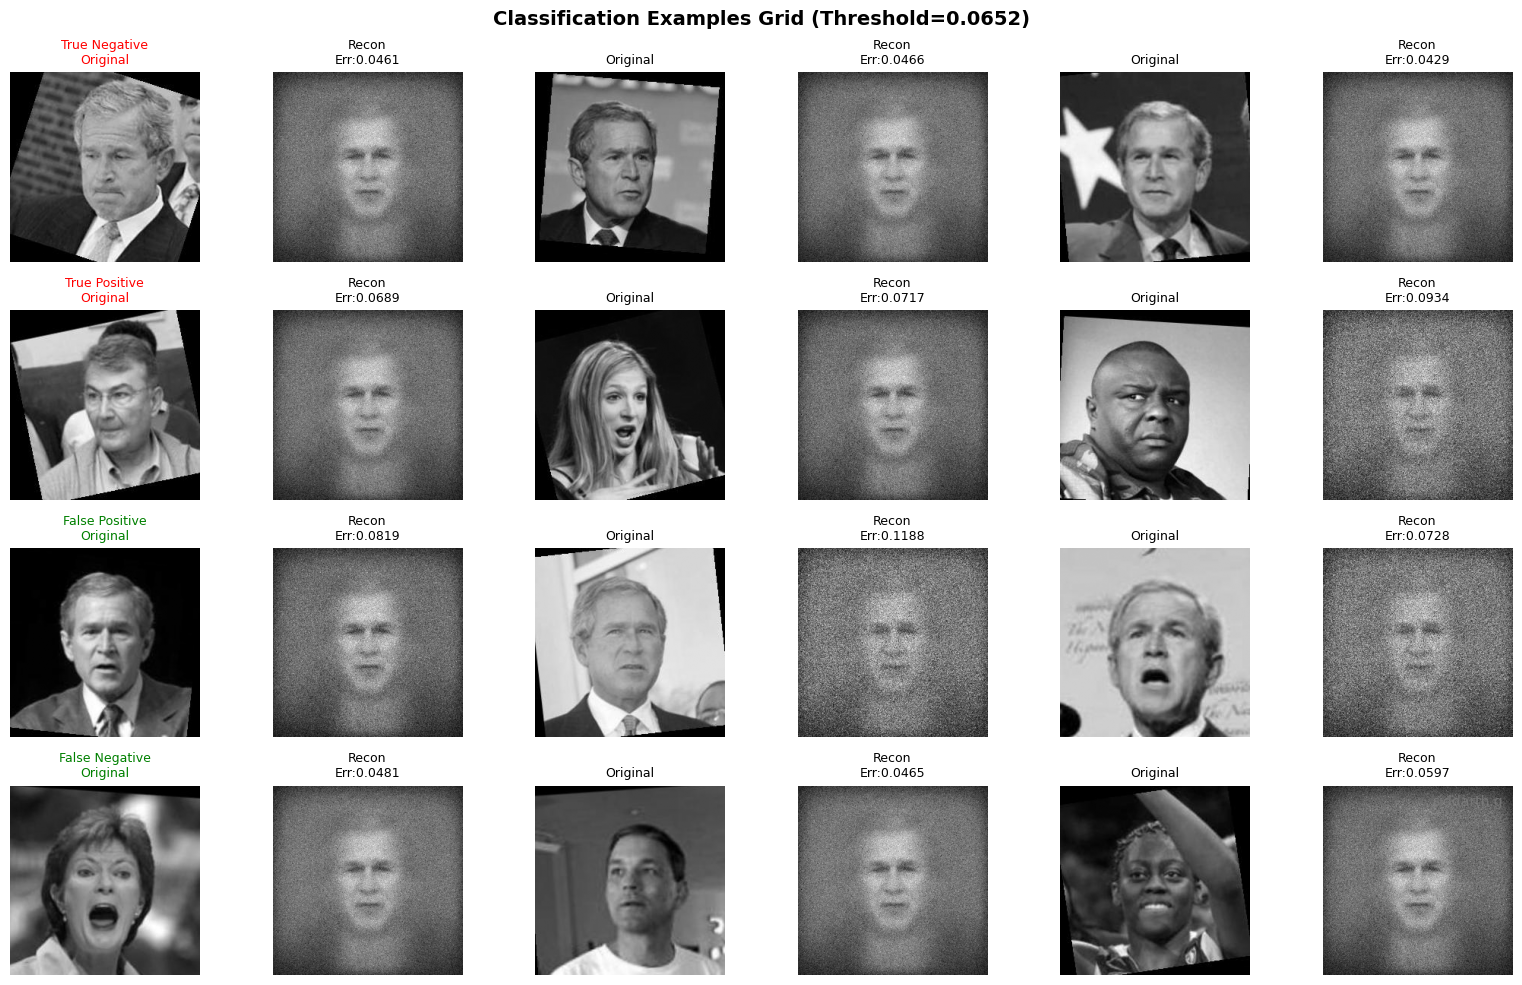

In [80]:

# Run comprehensive visualization
examples, avg_precision, pr_auc = comprehensive_visualization(
    autoencoder=best_autoencoder,
    X_test=X_test,
    y_test=y_test,
    reconstruction_errors=best_reconstruction_errors,
    threshold=best_threshold,
    y_pred=y_pred,
    img_shape=img_shape
)

# Create detailed comparison grid with multiple examples
print("\nCreating detailed comparison grid...")
create_detailed_comparison_grid(
    autoencoder=best_autoencoder,
    X_test=X_test,
    y_test=y_test,
    reconstruction_errors=best_reconstruction_errors,
    threshold=best_threshold,
    y_pred=y_pred,
    img_shape=img_shape,
    n_examples=3
)